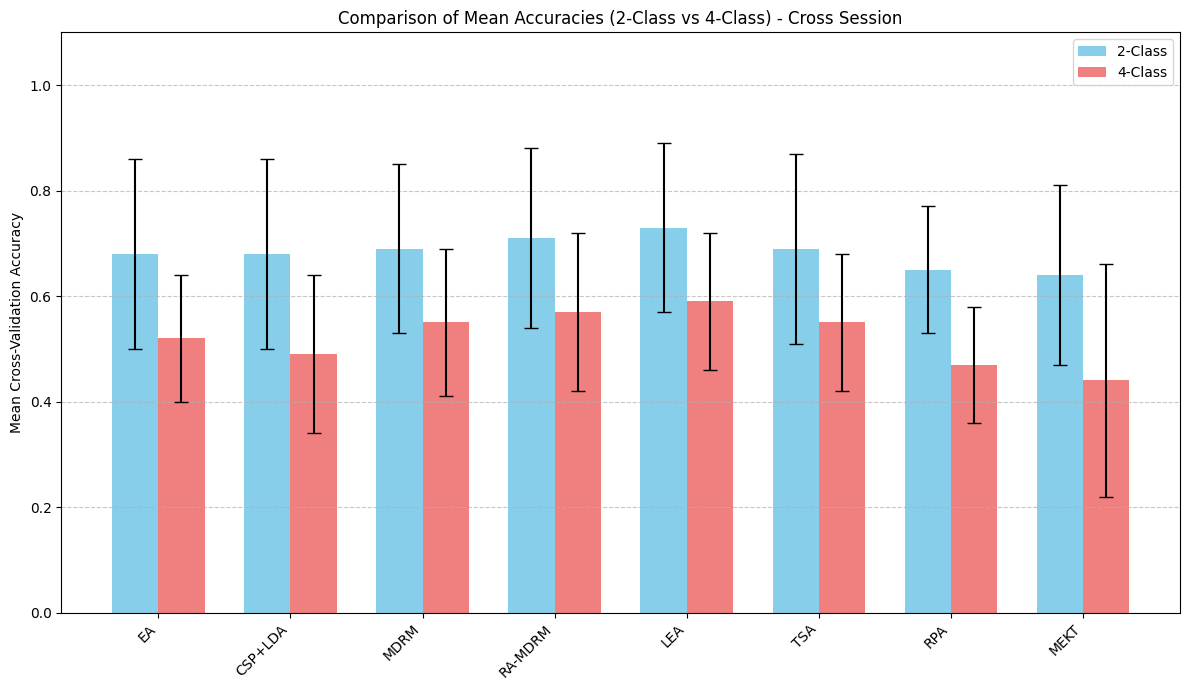

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
methods = ['EA', 'CSP+LDA', 'MDRM', 'RA-MDRM', 'LEA', 'TSA', 'RPA', 'MEKT']
mean_acc_2class = [0.68, 0.68, 0.69, 0.71, 0.73, 0.69, 0.65, 0.64]
std_dev_2class = [0.18, 0.18, 0.16, 0.17, 0.16, 0.18, 0.12, 0.17]
mean_acc_4class = [0.52, 0.49, 0.55, 0.57, 0.59, 0.55, 0.47, 0.44]
std_dev_4class = [0.12, 0.15, 0.14, 0.15, 0.13, 0.13, 0.11, 0.22]

# --- Plotting ---
x = np.arange(len(methods))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7)) # Increase figure size for better readability

# Create bars for 2-class results
rects1 = ax.bar(x - width/2, mean_acc_2class, width, label='2-Class', 
                yerr=std_dev_2class, capsize=5, color='skyblue')

# Create bars for 4-class results
rects2 = ax.bar(x + width/2, mean_acc_4class, width, label='4-Class', 
                yerr=std_dev_4class, capsize=5, color='lightcoral')

# --- Add labels, title, and custom x-axis tick labels ---
ax.set_ylabel('Mean Cross-Validation Accuracy')
ax.set_title('Comparison of Mean Accuracies (2-Class vs 4-Class) - Cross Session')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha="right") # Rotate labels if they overlap
ax.set_ylim(0, 1.1) # Set y-axis limits (0 to 1 or slightly above for accuracy)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines

# Add value labels on top of bars (optional, can be cluttered)
# ax.bar_label(rects1, padding=3, fmt='%.2f')
# ax.bar_label(rects2, padding=3, fmt='%.2f')

fig.tight_layout() # Adjust layout to prevent labels overlapping

# --- Show Plot ---
plt.show()

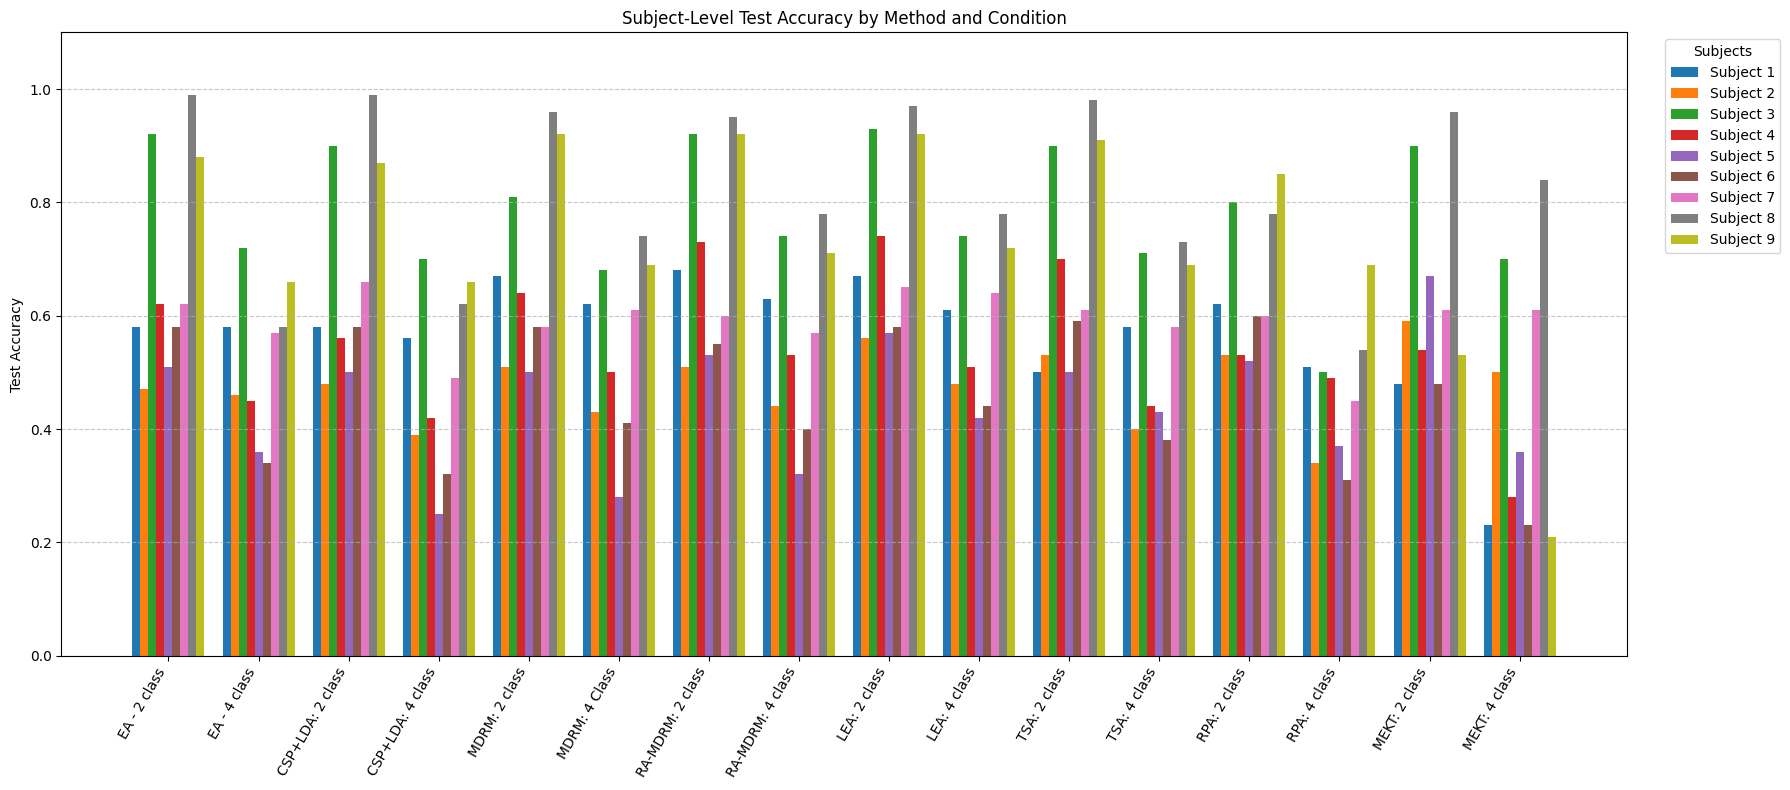

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data ---
# (Using the same data structure as the heatmap example)
methods_conditions = [
    'EA - 2 class', 'EA - 4 class',
    'CSP+LDA: 2 class', 'CSP+LDA: 4 class',
    'MDRM: 2 class', 'MDRM: 4 Class',
    'RA-MDRM: 2 class', 'RA-MDRM: 4 class',
    'LEA: 2 class', 'LEA: 4 class',
    'TSA: 2 class', 'TSA: 4 class',
    'RPA: 2 class', 'RPA: 4 class',
    'MEKT: 2 class', 'MEKT: 4 class'
]

subject_accuracies = [
    # S1   S2    S3    S4    S5    S6    S7    S8    S9
    [0.58, 0.47, 0.92, 0.62, 0.51, 0.58, 0.62, 0.99, 0.88], # EA - 2 class
    [0.58, 0.46, 0.72, 0.45, 0.36, 0.34, 0.57, 0.58, 0.66], # EA - 4 class
    [0.58, 0.48, 0.90, 0.56, 0.50, 0.58, 0.66, 0.99, 0.87], # CSP+LDA: 2 class
    [0.56, 0.39, 0.70, 0.42, 0.25, 0.32, 0.49, 0.62, 0.66], # CSP+LDA: 4 class
    [0.67, 0.51, 0.81, 0.64, 0.50, 0.58, 0.58, 0.96, 0.92], # MDRM: 2 class
    [0.62, 0.43, 0.68, 0.50, 0.28, 0.41, 0.61, 0.74, 0.69], # MDRM: 4 Class
    [0.68, 0.51, 0.92, 0.73, 0.53, 0.55, 0.60, 0.95, 0.92], # RA-MDRM: 2 class
    [0.63, 0.44, 0.74, 0.53, 0.32, 0.40, 0.57, 0.78, 0.71], # RA-MDRM: 4 class
    [0.67, 0.56, 0.93, 0.74, 0.57, 0.58, 0.65, 0.97, 0.92], # LEA: 2 class
    [0.61, 0.48, 0.74, 0.51, 0.42, 0.44, 0.64, 0.78, 0.72], # LEA: 4 class
    [0.50, 0.53, 0.90, 0.70, 0.50, 0.59, 0.61, 0.98, 0.91], # TSA: 2 class
    [0.58, 0.40, 0.71, 0.44, 0.43, 0.38, 0.58, 0.73, 0.69], # TSA: 4 class
    [0.62, 0.53, 0.80, 0.53, 0.52, 0.60, 0.60, 0.78, 0.85], # RPA: 2 class
    [0.51, 0.34, 0.50, 0.49, 0.37, 0.31, 0.45, 0.54, 0.69], # RPA: 4 class
    [0.48, 0.59, 0.90, 0.54, 0.67, 0.48, 0.61, 0.96, 0.53], # MEKT: 2 class
    [0.23, 0.50, 0.70, 0.28, 0.36, 0.23, 0.61, 0.84, 0.21]  # MEKT: 4 class
]

# Convert to DataFrame (Subjects as columns, Methods as rows)
df = pd.DataFrame(subject_accuracies, index=methods_conditions,
                  columns=[f'Subject {i+1}' for i in range(9)])

# --- Plotting ---
num_subjects = len(df.columns)
num_methods = len(df.index)

x = np.arange(num_methods)  # the label locations (one per method/condition)
width = 0.8 / num_subjects # Calculate width for each bar to fit within the group space
                               # 0.8 gives a little space between groups

fig, ax = plt.subplots(figsize=(20, 8)) # Use a wider figure size

# Create bars for each subject
for i, subject in enumerate(df.columns):
    # Calculate the offset for each subject's bar within the group
    offset = width * (i - num_subjects / 2) + width / 2
    rects = ax.bar(x + offset, df[subject], width, label=subject)

# --- Add labels, title, and custom x-axis tick labels ---
ax.set_ylabel('Test Accuracy')
ax.set_title('Subject-Level Test Accuracy by Method and Condition')
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=60, ha="right") # Rotate labels more for visibility
ax.set_ylim(0, 1.1) # Set y-axis limits
ax.legend(title='Subjects', bbox_to_anchor=(1.02, 1), loc='upper left') # Place legend outside plot area
ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legend

# --- Show Plot ---
plt.show()

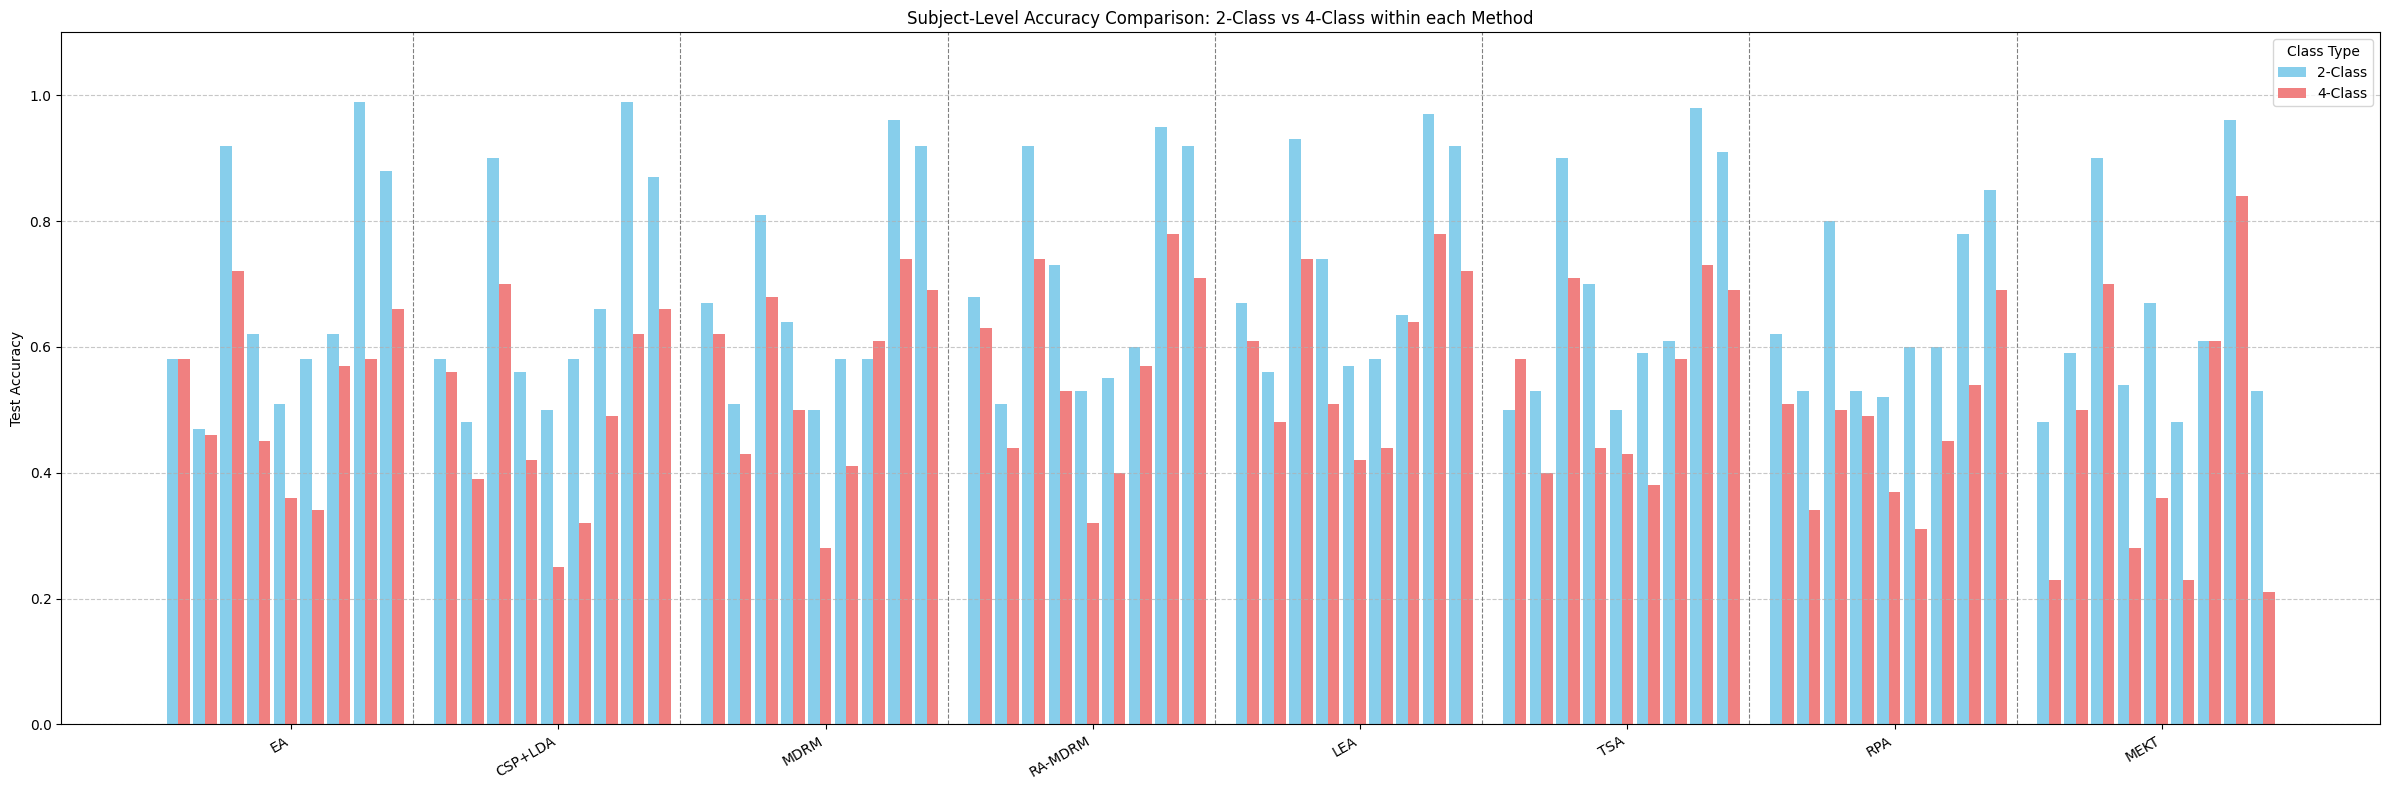

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data Reorganization ---
# Original data structure might need adjustment for this plot type.
# Let's create lists for each method containing tuples of (2-class acc, 4-class acc) per subject.

methods = ['EA', 'CSP+LDA', 'MDRM', 'RA-MDRM', 'LEA', 'TSA', 'RPA', 'MEKT']
num_methods = len(methods)
num_subjects = 9
subjects = [f'Subject {i+1}' for i in range(num_subjects)]

# Data structured as: Method -> Subject -> (2-class Acc, 4-class Acc)
data = {
    'EA':      [(0.58, 0.58), (0.47, 0.46), (0.92, 0.72), (0.62, 0.45), (0.51, 0.36), (0.58, 0.34), (0.62, 0.57), (0.99, 0.58), (0.88, 0.66)],
    'CSP+LDA': [(0.58, 0.56), (0.48, 0.39), (0.90, 0.70), (0.56, 0.42), (0.50, 0.25), (0.58, 0.32), (0.66, 0.49), (0.99, 0.62), (0.87, 0.66)],
    'MDRM':    [(0.67, 0.62), (0.51, 0.43), (0.81, 0.68), (0.64, 0.50), (0.50, 0.28), (0.58, 0.41), (0.58, 0.61), (0.96, 0.74), (0.92, 0.69)],
    'RA-MDRM': [(0.68, 0.63), (0.51, 0.44), (0.92, 0.74), (0.73, 0.53), (0.53, 0.32), (0.55, 0.40), (0.60, 0.57), (0.95, 0.78), (0.92, 0.71)],
    'LEA':     [(0.67, 0.61), (0.56, 0.48), (0.93, 0.74), (0.74, 0.51), (0.57, 0.42), (0.58, 0.44), (0.65, 0.64), (0.97, 0.78), (0.92, 0.72)],
    'TSA':     [(0.50, 0.58), (0.53, 0.40), (0.90, 0.71), (0.70, 0.44), (0.50, 0.43), (0.59, 0.38), (0.61, 0.58), (0.98, 0.73), (0.91, 0.69)],
    'RPA':     [(0.62, 0.51), (0.53, 0.34), (0.80, 0.50), (0.53, 0.49), (0.52, 0.37), (0.60, 0.31), (0.60, 0.45), (0.78, 0.54), (0.85, 0.69)],
    'MEKT':    [(0.48, 0.23), (0.59, 0.50), (0.90, 0.70), (0.54, 0.28), (0.67, 0.36), (0.48, 0.23), (0.61, 0.61), (0.96, 0.84), (0.53, 0.21)],
}

# --- Plotting Calculations ---
bar_width = 0.35  # Width of a single bar (2c or 4c)
subject_group_width = bar_width * 2 # Width for a pair of bars (2c + 4c)
subject_padding = 0.1 # Padding between subject pairs within a method group
method_group_padding = 0.8 # Padding between different method groups

# Calculate x-coordinates for the center of each subject's bar pair
x_coords = []
tick_coords = []
tick_labels = []
current_pos = 0

for i_method, method in enumerate(methods):
    method_center = current_pos + (num_subjects * (subject_group_width + subject_padding) - subject_padding) / 2
    tick_coords.append(method_center)
    tick_labels.append(method)
    for i_subject in range(num_subjects):
        subject_center = current_pos + bar_width/2 # Center of the pair
        x_coords.append((subject_center - bar_width/2, subject_center + bar_width/2)) # Store left (2c) and right (4c) edge coords
        current_pos += subject_group_width + subject_padding
    current_pos += method_group_padding # Add padding after each method group


# --- Plotting ---
fig, ax = plt.subplots(figsize=(24, 8)) # Need a very wide figure

# Flatten data for plotting
acc_2class = [data[m][s][0] for m in methods for s in range(num_subjects)]
acc_4class = [data[m][s][1] for m in methods for s in range(num_subjects)]

# Get flattened x-coordinates for 2-class and 4-class bars
x_coords_flat = np.array(x_coords).flatten() # Contains alternating 2c_x, 4c_x positions
x_coords_2c = x_coords_flat[0::2] # Positions for 2-class bars
x_coords_4c = x_coords_flat[1::2] # Positions for 4-class bars

# Plot the bars
bars1 = ax.bar(x_coords_2c, acc_2class, bar_width, label='2-Class', color='skyblue')
bars2 = ax.bar(x_coords_4c, acc_4class, bar_width, label='4-Class', color='lightcoral')

# --- Add labels, title, ticks, etc. ---
ax.set_ylabel('Test Accuracy')
ax.set_title('Subject-Level Accuracy Comparison: 2-Class vs 4-Class within each Method')
ax.set_ylim(0, 1.1)
ax.legend(title='Class Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set method labels as major ticks
ax.set_xticks(tick_coords)
ax.set_xticklabels(tick_labels, rotation=30, ha='right')

# Add subject labels as minor ticks (optional, might be too cluttered)
# minor_tick_coords = [ (pair[0] + pair[1]) / 2 for pair in x_coords] # Center of each subject pair
# subject_tick_labels = [f'S{s+1}' for m in methods for s in range(num_subjects)]
# ax.set_xticks(minor_tick_coords, minor=True)
# ax.set_xticklabels(subject_tick_labels, minor=True, rotation=90, fontsize=6)
# ax.tick_params(axis='x', which='minor', pad=-10) # Adjust minor tick label position if needed

# Add separators between methods (optional)
for i in range(num_methods - 1):
    separator_pos = tick_coords[i] + (tick_coords[i+1] - tick_coords[i])/2 - method_group_padding/2 + subject_padding/2
    ax.axvline(separator_pos, color='grey', linestyle='--', linewidth=0.8)


fig.tight_layout() # Adjust layout

# --- Show Plot ---
plt.show()

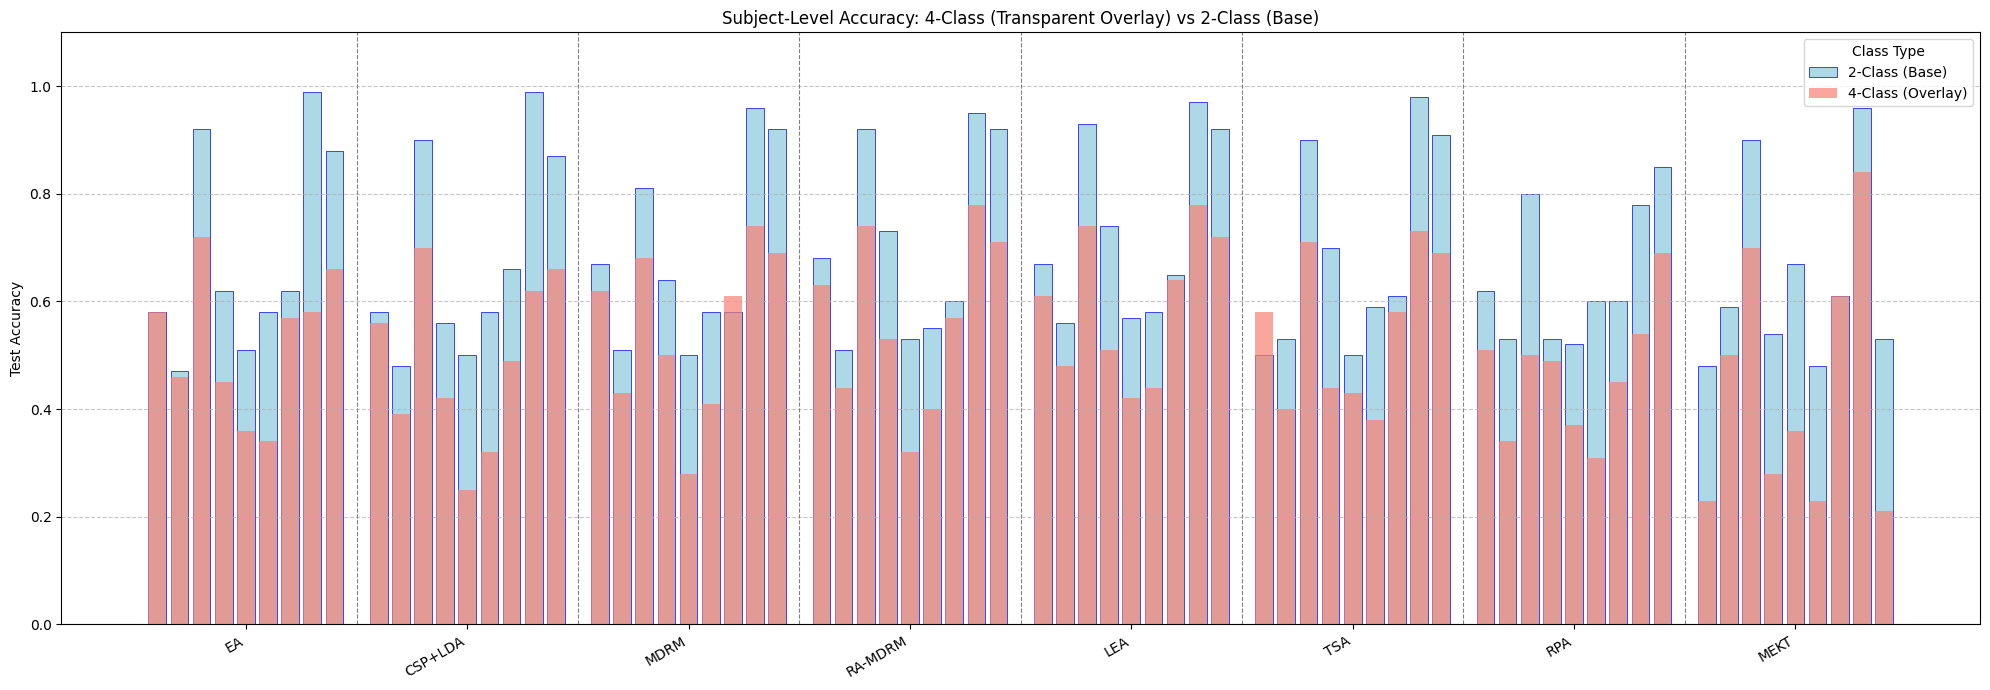

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data Reorganization ---
# (Using the same data structure as the previous example)
methods = ['EA', 'CSP+LDA', 'MDRM', 'RA-MDRM', 'LEA', 'TSA', 'RPA', 'MEKT']
num_methods = len(methods)
num_subjects = 9
subjects = [f'Subject {i+1}' for i in range(num_subjects)]

data = {
    'EA':      [(0.58, 0.58), (0.47, 0.46), (0.92, 0.72), (0.62, 0.45), (0.51, 0.36), (0.58, 0.34), (0.62, 0.57), (0.99, 0.58), (0.88, 0.66)],
    'CSP+LDA': [(0.58, 0.56), (0.48, 0.39), (0.90, 0.70), (0.56, 0.42), (0.50, 0.25), (0.58, 0.32), (0.66, 0.49), (0.99, 0.62), (0.87, 0.66)],
    'MDRM':    [(0.67, 0.62), (0.51, 0.43), (0.81, 0.68), (0.64, 0.50), (0.50, 0.28), (0.58, 0.41), (0.58, 0.61), (0.96, 0.74), (0.92, 0.69)],
    'RA-MDRM': [(0.68, 0.63), (0.51, 0.44), (0.92, 0.74), (0.73, 0.53), (0.53, 0.32), (0.55, 0.40), (0.60, 0.57), (0.95, 0.78), (0.92, 0.71)],
    'LEA':     [(0.67, 0.61), (0.56, 0.48), (0.93, 0.74), (0.74, 0.51), (0.57, 0.42), (0.58, 0.44), (0.65, 0.64), (0.97, 0.78), (0.92, 0.72)],
    'TSA':     [(0.50, 0.58), (0.53, 0.40), (0.90, 0.71), (0.70, 0.44), (0.50, 0.43), (0.59, 0.38), (0.61, 0.58), (0.98, 0.73), (0.91, 0.69)],
    'RPA':     [(0.62, 0.51), (0.53, 0.34), (0.80, 0.50), (0.53, 0.49), (0.52, 0.37), (0.60, 0.31), (0.60, 0.45), (0.78, 0.54), (0.85, 0.69)],
    'MEKT':    [(0.48, 0.23), (0.59, 0.50), (0.90, 0.70), (0.54, 0.28), (0.67, 0.36), (0.48, 0.23), (0.61, 0.61), (0.96, 0.84), (0.53, 0.21)],
}

# --- Plotting Calculations ---
bar_width = 0.8  # Width of the bars (can be wider now as they overlap)
subject_padding = 0.2 # Padding between subject bars within a method group
method_group_padding = 1.0 # Padding between different method groups

# Calculate x-coordinates for the center of each subject's bar
x_coords_center = []
tick_coords = [] # For method labels
tick_labels = []
current_pos = 0

for i_method, method in enumerate(methods):
    method_start_pos = current_pos
    for i_subject in range(num_subjects):
        subject_center = current_pos + bar_width / 2
        x_coords_center.append(subject_center)
        current_pos += bar_width + subject_padding
    method_end_pos = current_pos - subject_padding # Position after last bar in group
    method_center_pos = (method_start_pos + method_end_pos) / 2
    tick_coords.append(method_center_pos)
    tick_labels.append(method)
    current_pos += method_group_padding # Add padding after each method group


# --- Plotting ---
fig, ax = plt.subplots(figsize=(20, 7)) # Adjust figure size

# Flatten data for plotting
acc_2class = [data[m][s][0] for m in methods for s in range(num_subjects)]
acc_4class = [data[m][s][1] for m in methods for s in range(num_subjects)]

# Plot the 2-class bars (bottom layer, fully opaque)
# Using a lighter color or just edgecolor might be better visually
bars1 = ax.bar(x_coords_center, acc_2class, bar_width,
               label='2-Class (Base)', color='lightblue', edgecolor='blue', linewidth=0.5)

# Plot the 4-class bars (top layer, semi-transparent)
# Using a distinct, slightly darker color helps
bars2 = ax.bar(x_coords_center, acc_4class, bar_width, # Same positions and width
               label='4-Class (Overlay)', color='salmon', alpha=0.7) # ALPHA makes it transparent


# --- Add labels, title, ticks, etc. ---
ax.set_ylabel('Test Accuracy')
ax.set_title('Subject-Level Accuracy: 4-Class (Transparent Overlay) vs 2-Class (Base)')
ax.set_ylim(0, 1.1)
ax.legend(title='Class Type')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set method labels as major ticks
ax.set_xticks(tick_coords)
ax.set_xticklabels(tick_labels, rotation=30, ha='right')

# Add subject labels as minor ticks (optional, can be VERY cluttered)
# subject_tick_labels = [f'S{s+1}' for m in methods for s in range(num_subjects)]
# ax.set_xticks(x_coords_center, minor=True)
# ax.set_xticklabels(subject_tick_labels, minor=True, rotation=90, fontsize=6)
# ax.tick_params(axis='x', which='minor', length=0) # Hide minor tick lines if desired

# Add separators between methods (optional)
for i in range(num_methods - 1):
     separator_pos = tick_coords[i] + (tick_coords[i+1] - tick_coords[i]) / 2
     ax.axvline(separator_pos, color='grey', linestyle='--', linewidth=0.8)


fig.tight_layout() # Adjust layout

# --- Show Plot ---
plt.show()